Label Analysis Summary:
--------------------------------------------------
Label counts:
label
-2     10359
-1      7176
 0    258690
 1      7341
 2     10194
Name: count, dtype: int64

Label percentages (% of total data):
label
-2     3.526348
-1     2.442810
 0    88.061683
 1     2.498979
 2     3.470180
Name: count, dtype: float64

Total trading signals: 35070 (11.94% of data)
Long entries: 17535 (50.00% of signals)
Short entries: 17535 (50.00% of signals)

Win Rate Analysis:
Long win rate: 41.86%
Short win rate: 40.92%
Overall win rate: 41.39%


/tmp/ipykernel_8051/4193068869.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


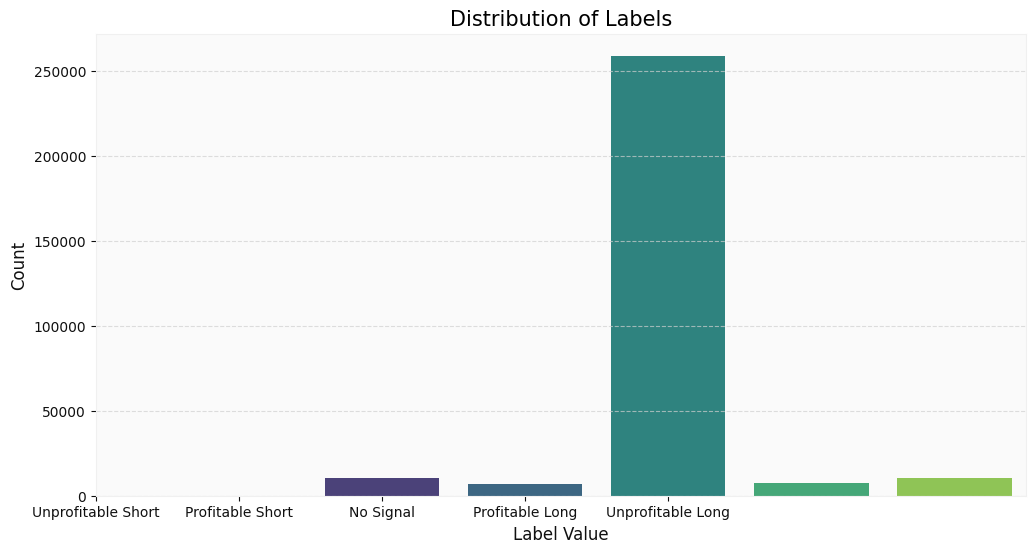


Price characteristics by label:
             close             tema_distance                                \
              mean         std          mean       std       min       max   
label                                                                        
-2     2075.423850  166.354333 -2.639892e-04  0.000578 -0.011857  0.004705   
-1     2069.189394  164.938829 -2.734809e-04  0.000537 -0.010313  0.003288   
 0     2070.408035  165.874235  9.306270e-07  0.000842 -0.017337  0.025123   
 1     2069.659495  165.231035  2.664393e-04  0.000561 -0.006644  0.010544   
 2     2075.145128  166.167819  2.643028e-04  0.000590 -0.008784  0.008432   

      atr_percent                volume              
             mean       std        mean         std  
label                                                
-2       0.000395  0.000367  289.773428  604.642359  
-1       0.000365  0.000322  271.285338  589.912396  
 0       0.000379  0.000357  326.326728  848.117430  
 1       0.000359 

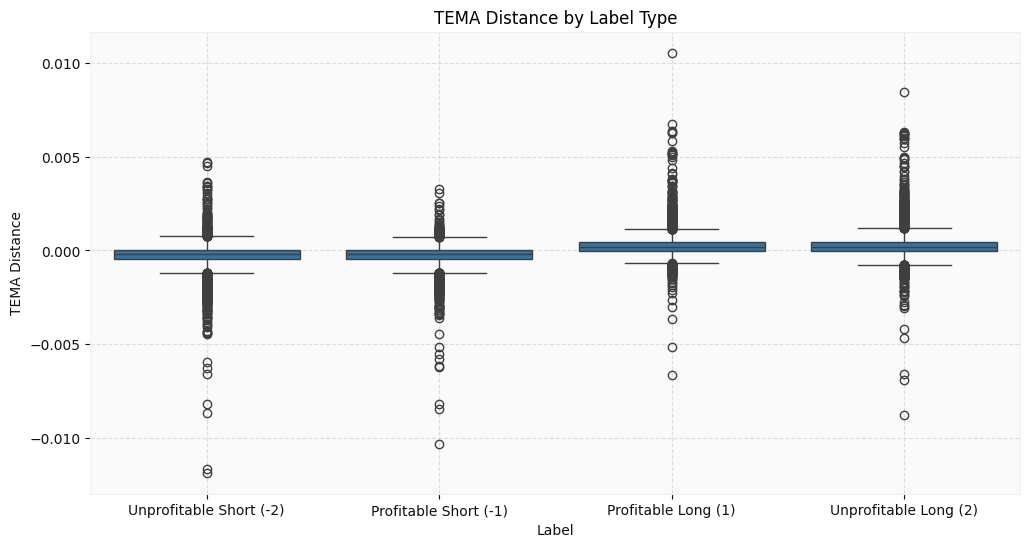

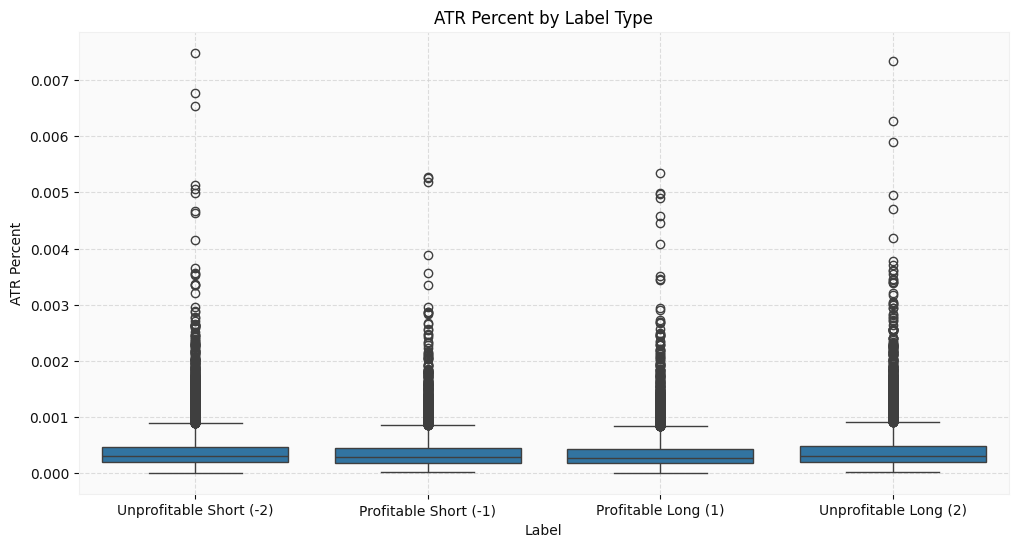


Trend distribution by label (%):
trend        DOWN          UP
label                        
-2     100.000000    0.000000
-1     100.000000    0.000000
 0      50.338437   49.661563
 1       0.000000  100.000000
 2       0.000000  100.000000


<Figure size 1200x600 with 0 Axes>

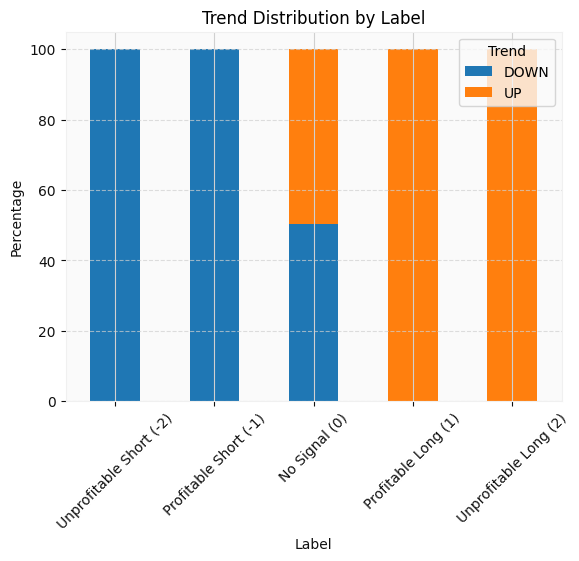


Label transition counts (rows: current label, columns: next label):
next_label  -2.0  -1.0     0.0   1.0   2.0
label                                     
-2             0     0    5906  1933  2520
-1             0     0    6980    25   171
 0          7633  5319  232851  5383  7503
 1           170    29    7142     0     0
 2          2556  1828    5810     0     0

Label transition probabilities (%):
next_label       -2.0       -1.0        0.0        1.0        2.0
label                                                            
-2           0.000000   0.000000  57.013225  18.660102  24.326672
-1           0.000000   0.000000  97.268673   0.348384   2.382943
 0           2.950647   2.056137  90.011945   2.080877   2.900394
 1           2.315761   0.395042  97.289198   0.000000   0.000000
 2          25.073573  17.932117  56.994310   0.000000   0.000000


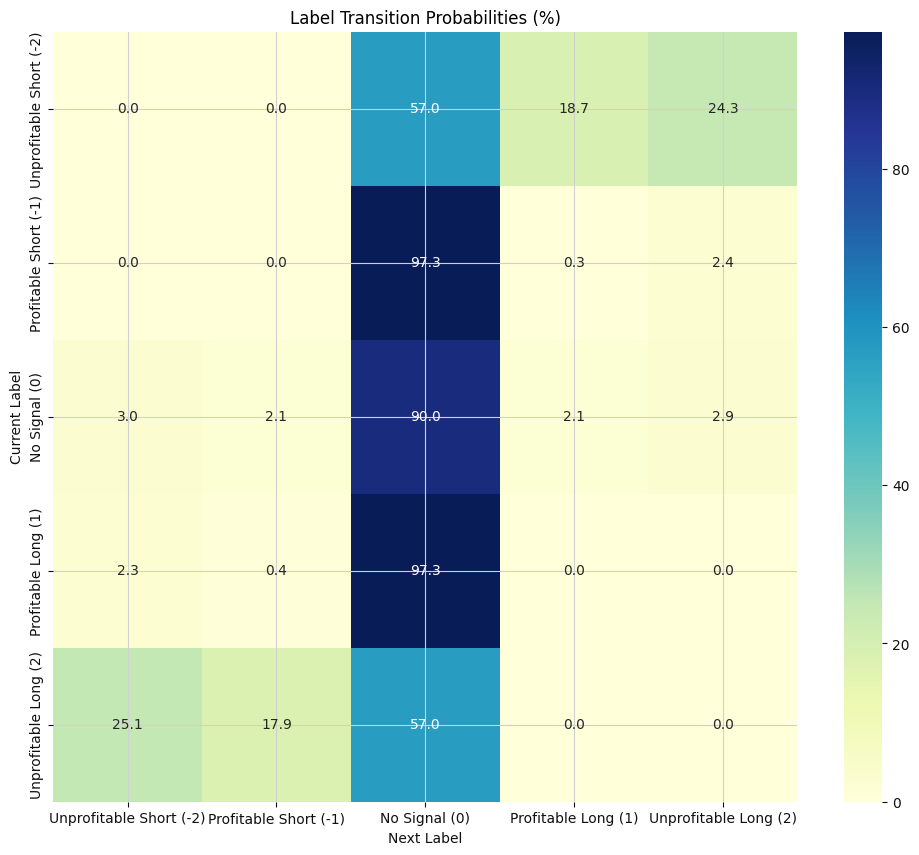

<Figure size 1400x700 with 0 Axes>

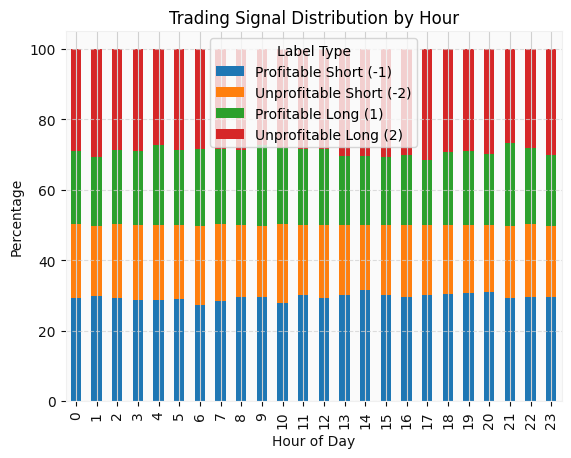

/tmp/ipykernel_8051/4193068869.py:156: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_winrate = df[df['label'] != 0].groupby('hour').apply(


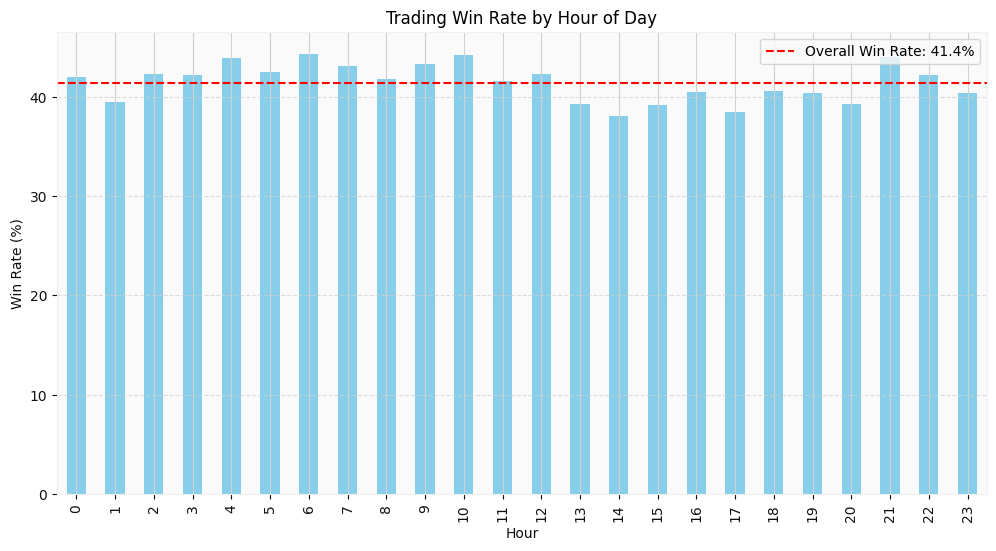


Analyzing features specific to each trade type:

Long trade characteristics (profitable vs unprofitable):
       tema_distance  atr_percent      volume
label                                        
1           0.000266     0.000359  269.001577
2           0.000264     0.000402  293.504179


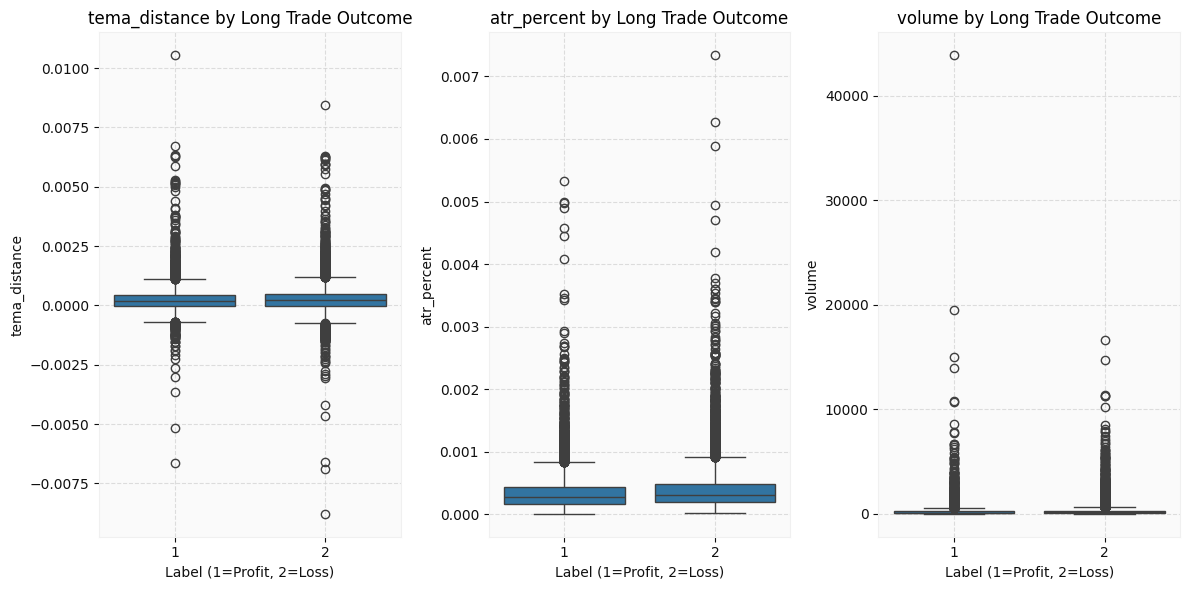


T-test for TEMA distance between profitable and unprofitable longs:
t-statistic: 0.2415, p-value: 0.8092

Short trade characteristics (profitable vs unprofitable):
       tema_distance  atr_percent      volume
label                                        
-2         -0.000264     0.000395  289.773428
-1         -0.000273     0.000365  271.285338


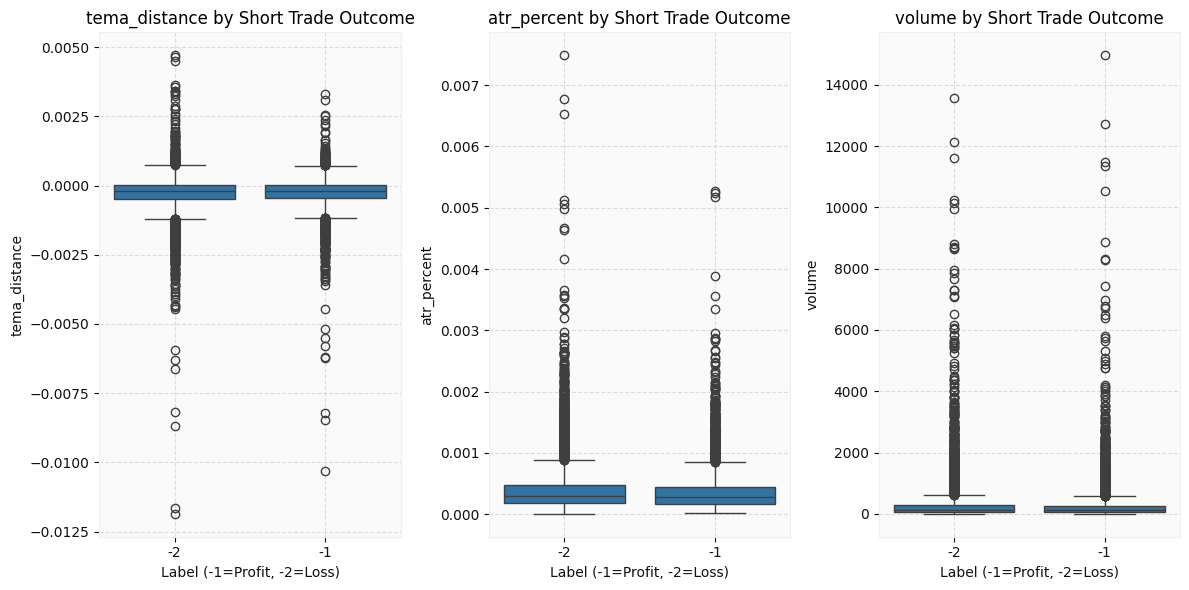


T-test for TEMA distance between profitable and unprofitable shorts:
t-statistic: -1.1000, p-value: 0.2713


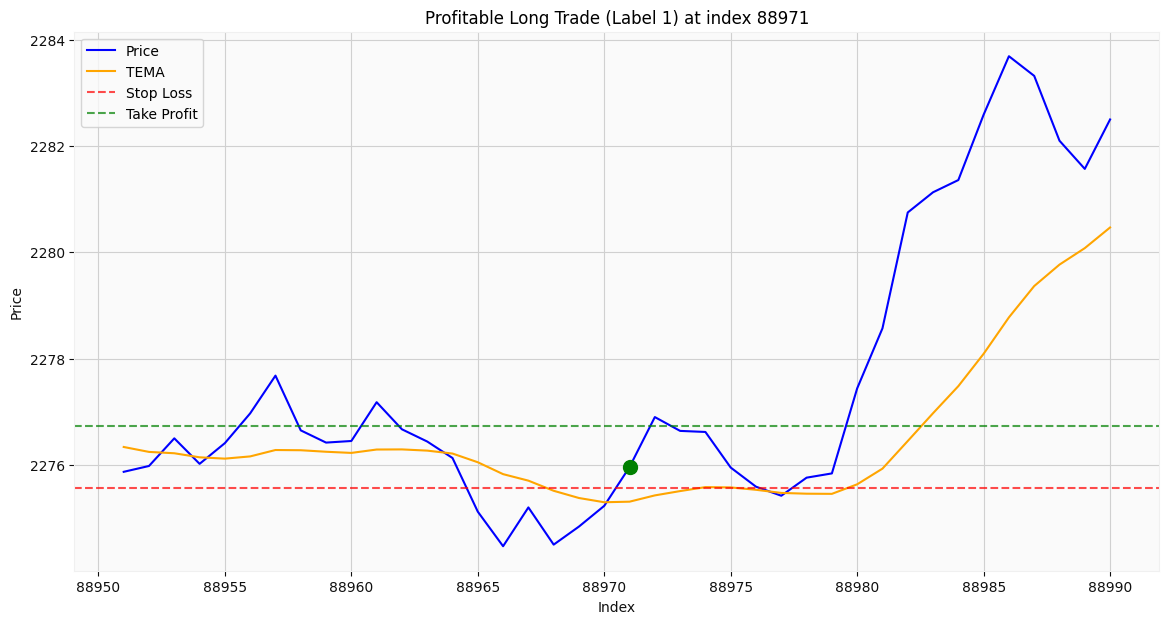

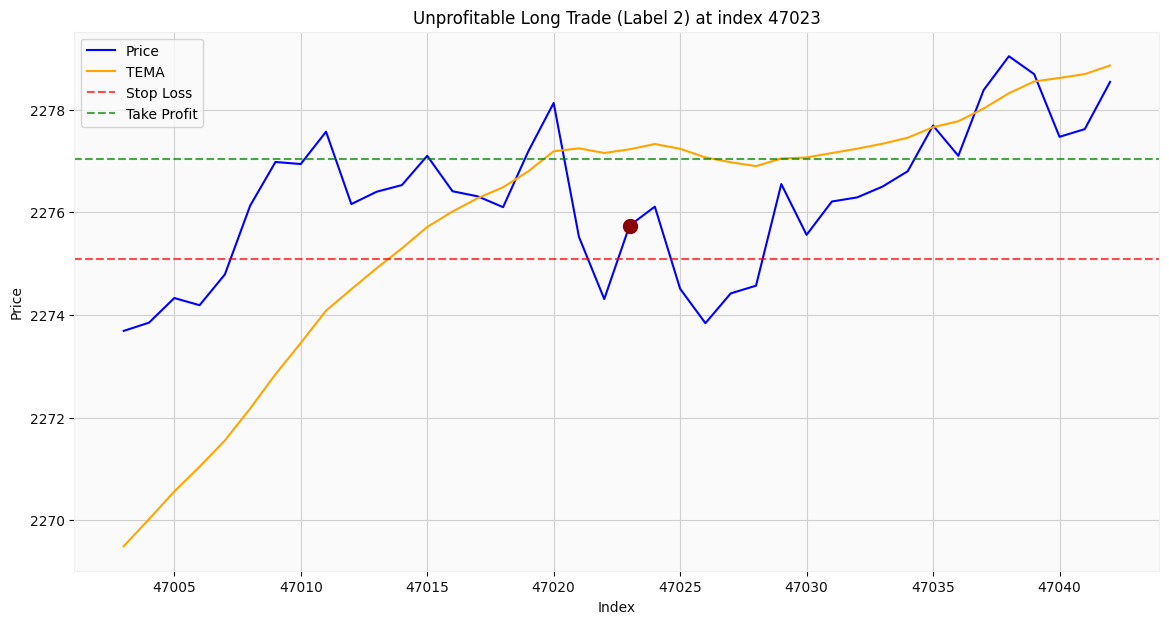

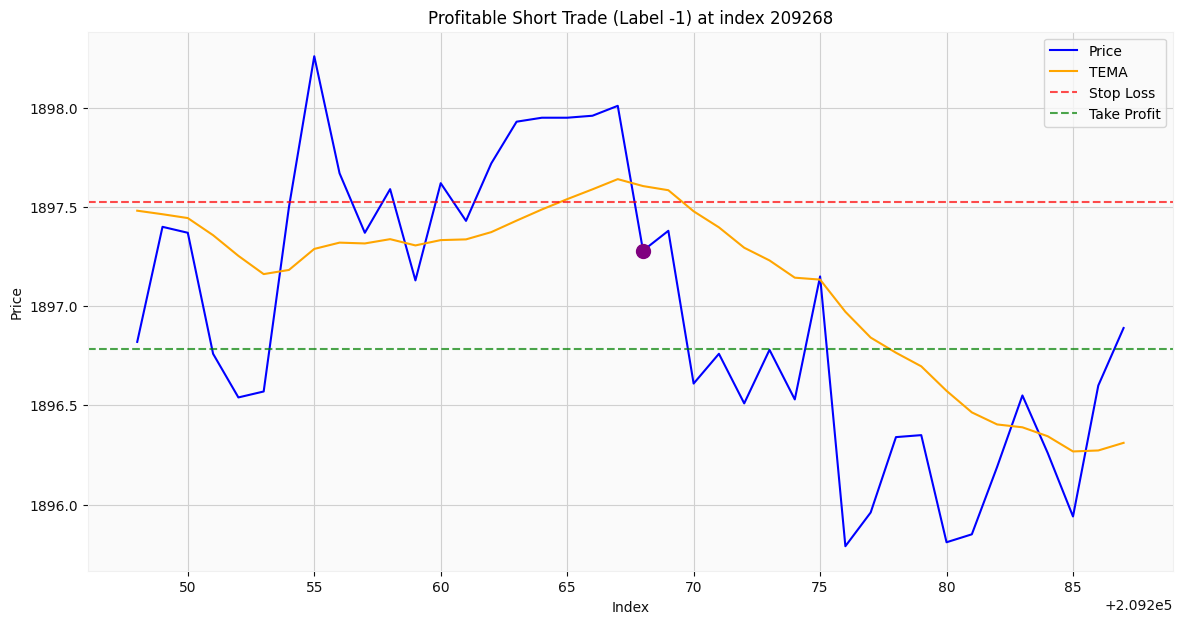

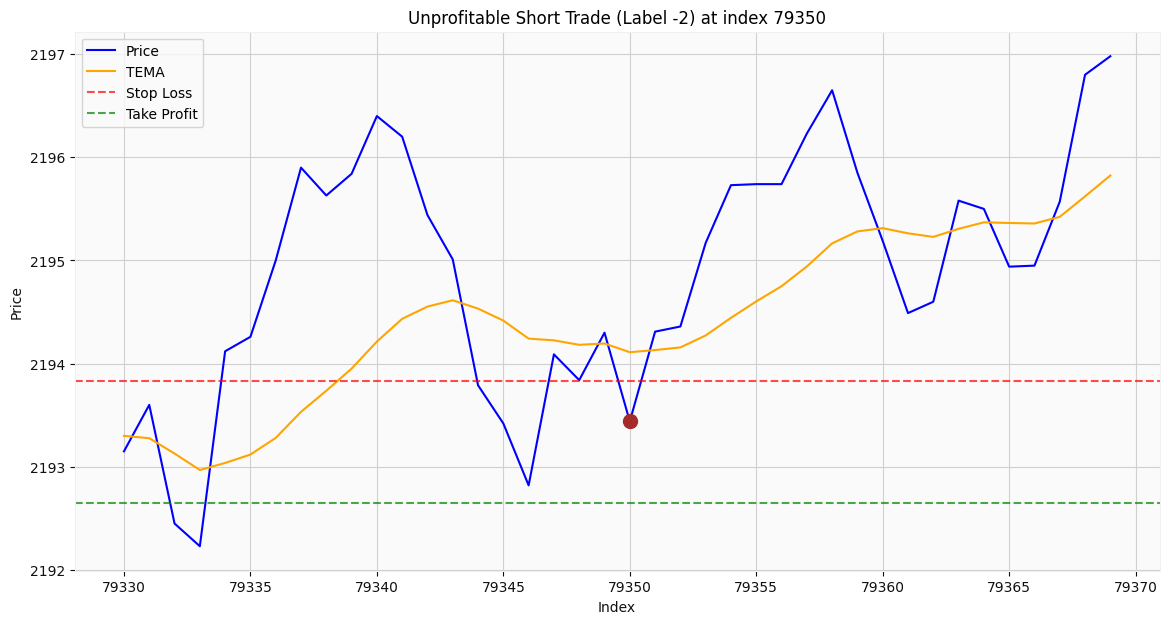


Label analysis complete.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the data
df = pd.read_parquet('labeled_ETH_USDT_USDT-5s-futures_r1_05.parquet')

# Label meaning based on the code:
# 0 = no entry/no signal
# 1 = profitable long (take profit hit)
# 2 = unprofitable long (stop loss hit)
# -1 = profitable short (take profit hit)
# -2 = unprofitable short (stop loss hit)

# Label analysis
print("Label Analysis Summary:")
print("-" * 50)
label_counts = df['label'].value_counts().sort_index()
print("Label counts:")
print(label_counts)

# Calculate percentages
label_pct = label_counts / len(df) * 100
print("\nLabel percentages (% of total data):")
print(label_pct)

# Calculate trade statistics
total_entries = df[(df['label'] != 0)].shape[0]
long_entries = df[(df['label'] == 1) | (df['label'] == 2)].shape[0]
short_entries = df[(df['label'] == -1) | (df['label'] == -2)].shape[0]

print(f"\nTotal trading signals: {total_entries} ({total_entries/len(df)*100:.2f}% of data)")
print(f"Long entries: {long_entries} ({long_entries/total_entries*100:.2f}% of signals)")
print(f"Short entries: {short_entries} ({short_entries/total_entries*100:.2f}% of signals)")

# Calculate win rates
profitable_longs = df[df['label'] == 1].shape[0]
unprofitable_longs = df[df['label'] == 2].shape[0]
profitable_shorts = df[df['label'] == -1].shape[0]
unprofitable_shorts = df[df['label'] == -2].shape[0]

long_win_rate = profitable_longs / long_entries * 100 if long_entries > 0 else 0
short_win_rate = profitable_shorts / short_entries * 100 if short_entries > 0 else 0
overall_win_rate = (profitable_longs + profitable_shorts) / total_entries * 100 if total_entries > 0 else 0

print("\nWin Rate Analysis:")
print(f"Long win rate: {long_win_rate:.2f}%")
print(f"Short win rate: {short_win_rate:.2f}%")
print(f"Overall win rate: {overall_win_rate:.2f}%")

# Visualization 1: Label Distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Labels', fontsize=15)
plt.xlabel('Label Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(ticks=[-2, -1, 0, 1, 2], 
           labels=['Unprofitable Short', 'Profitable Short', 'No Signal', 'Profitable Long', 'Unprofitable Long'])
plt.show()

# Analyze price movement around each label type
print("\nPrice characteristics by label:")
label_stats = df.groupby('label').agg({
    'close': ['mean', 'std'],
    'tema_distance': ['mean', 'std', 'min', 'max'],
    'atr_percent': ['mean', 'std'],
    'volume': ['mean', 'std'],
})
print(label_stats)

# Visualization 2: TEMA Distance by Label
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='tema_distance', data=df[df['label'] != 0])
plt.title('TEMA Distance by Label Type')
plt.xlabel('Label')
plt.ylabel('TEMA Distance')
plt.xticks(ticks=[0, 1, 2, 3], 
           labels=['Unprofitable Short (-2)', 'Profitable Short (-1)', 'Profitable Long (1)', 'Unprofitable Long (2)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualization 3: ATR Percent by Label
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='atr_percent', data=df[df['label'] != 0])
plt.title('ATR Percent by Label Type')
plt.xlabel('Label')
plt.ylabel('ATR Percent')
plt.xticks(ticks=[0, 1, 2, 3], 
           labels=['Unprofitable Short (-2)', 'Profitable Short (-1)', 'Profitable Long (1)', 'Unprofitable Long (2)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Analyze trend by label
trend_by_label = pd.crosstab(df['label'], df['trend'], normalize='index') * 100
print("\nTrend distribution by label (%):")
print(trend_by_label)

# Visualization 4: Trend by Label
plt.figure(figsize=(12, 6))
trend_by_label.plot(kind='bar', stacked=True)
plt.title('Trend Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.xticks(ticks=range(5), 
           labels=['Unprofitable Short (-2)', 'Profitable Short (-1)', 'No Signal (0)', 
                  'Profitable Long (1)', 'Unprofitable Long (2)'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.legend(title='Trend')
plt.show()

# Analyze consecutive signals
df['next_label'] = df['label'].shift(-1)
transition_matrix = pd.crosstab(df['label'], df['next_label'])
print("\nLabel transition counts (rows: current label, columns: next label):")
print(transition_matrix)

# Compute transition probabilities
transition_prob = pd.crosstab(df['label'], df['next_label'], normalize='index') * 100
print("\nLabel transition probabilities (%):")
print(transition_prob)

# Visualization 5: Transition Heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(transition_prob, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Label Transition Probabilities (%)')
plt.xlabel('Next Label')
plt.ylabel('Current Label')
ax.set_xticklabels(['Unprofitable Short (-2)', 'Profitable Short (-1)', 'No Signal (0)', 
                    'Profitable Long (1)', 'Unprofitable Long (2)'])
ax.set_yticklabels(['Unprofitable Short (-2)', 'Profitable Short (-1)', 'No Signal (0)', 
                    'Profitable Long (1)', 'Unprofitable Long (2)'])
plt.show()

# Calculate temporal characteristics
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek

# Visualization 6: Label distribution by hour
signal_hours = df[df['label'] != 0].groupby(['hour', 'label']).size().unstack().fillna(0)
signal_hours_pct = signal_hours.div(signal_hours.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
signal_hours_pct.plot(kind='bar', stacked=True)
plt.title('Trading Signal Distribution by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Percentage')
plt.legend(title='Label Type', labels=['Profitable Short (-1)', 'Unprofitable Short (-2)', 
                                      'Profitable Long (1)', 'Unprofitable Long (2)'])
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.show()

# Visualization 7: Win rate by hour
hourly_winrate = df[df['label'] != 0].groupby('hour').apply(
    lambda x: len(x[x['label'].isin([1, -1])]) / len(x) * 100 if len(x) > 0 else 0
)

plt.figure(figsize=(12, 6))
hourly_winrate.plot(kind='bar', color='skyblue')
plt.axhline(y=overall_win_rate, color='red', linestyle='--', 
            label=f'Overall Win Rate: {overall_win_rate:.1f}%')
plt.title('Trading Win Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Win Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.show()

# Feature importance analysis
# For long trades (1 vs 2)
print("\nAnalyzing features specific to each trade type:")

# Long trades analysis
long_df = df[(df['label'] == 1) | (df['label'] == 2)].copy()
if len(long_df) > 0:
    print("\nLong trade characteristics (profitable vs unprofitable):")
    long_comparison = long_df.groupby('label').agg({
        'tema_distance': 'mean',
        'atr_percent': 'mean',
        'volume': 'mean'
    })
    print(long_comparison)
    
    # Visualization 8: Long trade feature comparison
    plt.figure(figsize=(12, 6))
    features = ['tema_distance', 'atr_percent', 'volume']
    
    for i, feature in enumerate(features):
        plt.subplot(1, 3, i+1)
        sns.boxplot(x='label', y=feature, data=long_df)
        plt.title(f'{feature} by Long Trade Outcome')
        plt.xlabel('Label (1=Profit, 2=Loss)')
        plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical significance test
    tema_distance_ttest = stats.ttest_ind(
        long_df[long_df['label'] == 1]['tema_distance'].dropna(),
        long_df[long_df['label'] == 2]['tema_distance'].dropna()
    )
    print(f"\nT-test for TEMA distance between profitable and unprofitable longs:")
    print(f"t-statistic: {tema_distance_ttest.statistic:.4f}, p-value: {tema_distance_ttest.pvalue:.4f}")

# Short trades analysis
short_df = df[(df['label'] == -1) | (df['label'] == -2)].copy()
if len(short_df) > 0:
    print("\nShort trade characteristics (profitable vs unprofitable):")
    short_comparison = short_df.groupby('label').agg({
        'tema_distance': 'mean',
        'atr_percent': 'mean',
        'volume': 'mean'
    })
    print(short_comparison)
    
    # Visualization 9: Short trade feature comparison
    plt.figure(figsize=(12, 6))
    features = ['tema_distance', 'atr_percent', 'volume']
    
    for i, feature in enumerate(features):
        plt.subplot(1, 3, i+1)
        sns.boxplot(x='label', y=feature, data=short_df)
        plt.title(f'{feature} by Short Trade Outcome')
        plt.xlabel('Label (-1=Profit, -2=Loss)')
        plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical significance test
    tema_distance_ttest = stats.ttest_ind(
        short_df[short_df['label'] == -1]['tema_distance'].dropna(),
        short_df[short_df['label'] == -2]['tema_distance'].dropna()
    )
    print(f"\nT-test for TEMA distance between profitable and unprofitable shorts:")
    print(f"t-statistic: {tema_distance_ttest.statistic:.4f}, p-value: {tema_distance_ttest.pvalue:.4f}")

# Visualization 10: Price and TEMA for sample trade signals (show a few examples)
def plot_sample_trade(df, label_type, num_samples=3):
    # Filter for the specified label type
    sample_df = df[df['label'] == label_type]
    
    if len(sample_df) == 0:
        print(f"No trades with label {label_type} found")
        return
    
    # Select random samples
    samples = sample_df.sample(min(num_samples, len(sample_df)))
    
    for idx, row in samples.iterrows():
        # Extract a window of data around the signal
        window_size = 40  # 20 candles before and after
        start_idx = max(0, idx - window_size // 2)
        end_idx = min(len(df), idx + window_size // 2)
        window_df = df.iloc[start_idx:end_idx].copy()
        
        # Create plot
        plt.figure(figsize=(14, 7))
        
        # Plot price and TEMA
        plt.plot(window_df.index, window_df['close'], label='Price', color='blue')
        plt.plot(window_df.index, window_df['tema'], label='TEMA', color='orange')
        
        # Mark the signal
        entry_price = row['close']
        atr_value = row['atr']
        
        # Different colors for different trade types
        if label_type == 1:  # Profitable long
            marker_color = 'green'
            title = f"Profitable Long Trade (Label 1) at index {idx}"
            # Calculate stop loss and take profit levels
            stop_loss = entry_price - (atr_value * 0.5)
            take_profit = entry_price + (atr_value * 1.0)
        elif label_type == 2:  # Unprofitable long
            marker_color = 'darkred'
            title = f"Unprofitable Long Trade (Label 2) at index {idx}"
            stop_loss = entry_price - (atr_value * 0.5)
            take_profit = entry_price + (atr_value * 1.0)
        elif label_type == -1:  # Profitable short
            marker_color = 'purple'
            title = f"Profitable Short Trade (Label -1) at index {idx}"
            stop_loss = entry_price + (atr_value * 0.5)
            take_profit = entry_price - (atr_value * 1.0)
        else:  # Unprofitable short
            marker_color = 'brown'
            title = f"Unprofitable Short Trade (Label -2) at index {idx}"
            stop_loss = entry_price + (atr_value * 0.5)
            take_profit = entry_price - (atr_value * 1.0)
        
        plt.scatter(idx, entry_price, color=marker_color, s=100, zorder=5)
        
        # Draw stop loss and take profit levels
        plt.axhline(y=stop_loss, color='red', linestyle='--', alpha=0.7, label='Stop Loss')
        plt.axhline(y=take_profit, color='green', linestyle='--', alpha=0.7, label='Take Profit')
        
        plt.title(title)
        plt.xlabel('Index')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.show()

# Plot sample trades for each label type
for label in [1, 2, -1, -2]:
    plot_sample_trade(df, label, num_samples=1)

print("\nLabel analysis complete.")


In [ ]:
# read 